# AI Automation Risk Predictor

## Data Loading
Dataset used: AI Powered Job Market Insights by Laksika Tharmalingam

https://www.kaggle.com/datasets/uom190346a/ai-powered-job-market-insights

Data is saved locally.

In [28]:
import pandas as pd

df = pd.read_csv("../data/ai_job_market_insights.csv")
print(f"Observations, Features: {df.shape}")
df.head(20)

Observations, Features: (500, 10)


,Job_Title,Industry,Company_Size,Location,AI_Adoption_Level,Automation_Risk,Required_Skills,Salary_USD,Remote_Friendly,Job_Growth_Projection
0,Cybersecurity Analyst,Entertainment,Small,Dubai,Medium,High,UX/UI Design,111392.165243,Yes,Growth
1,Marketing Specialist,Technology,Large,Singapore,Medium,High,Marketing,93792.562466,No,Decline
2,AI Researcher,Technology,Large,Singapore,Medium,High,UX/UI Design,107170.263069,Yes,Growth
3,Sales Manager,Retail,Small,Berlin,Low,High,Project Management,93027.953758,No,Growth
4,Cybersecurity Analyst,Entertainment,Small,Tokyo,Low,Low,JavaScript,87752.922171,Yes,Decline
5,UX Designer,Education,Large,San Francisco,Medium,Medium,Cybersecurity,102825.007867,No,Growth
6,HR Manager,Finance,Medium,Singapore,Low,High,Sales,102065.720673,Yes,Growth
7,Cybersecurity Analyst,Technology,Small,Dubai,Medium,Low,Machine Learning,86607.317618,Yes,Decline
8,AI Researcher,Retail,Large,London,High,Low,JavaScript,75015.860846,No,Stable
9,Sales Manager,Entertainment,Medium,Singapore,High,Low,Cybersecurity,96834.578295,Yes,Decline


## Data Cleaning

In [29]:
# Check for missing values
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"\nDataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")

Job_Title                0
Industry                 0
Company_Size             0
Location                 0
AI_Adoption_Level        0
Automation_Risk          0
Required_Skills          0
Salary_USD               0
Remote_Friendly          0
Job_Growth_Projection    0
dtype: int64

Total missing values: 0

Dataset shape: (500, 10)

Column names: ['Job_Title', 'Industry', 'Company_Size', 'Location', 'AI_Adoption_Level', 'Automation_Risk', 'Required_Skills', 'Salary_USD', 'Remote_Friendly', 'Job_Growth_Projection']


In [30]:
# Check for redundant features
print(f"Duplicate rows: {df.duplicated().sum()}")

# Check unique values per column
print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values -> {df[col].unique()[:10]}")

Duplicate rows: 0

Unique values per column:
Job_Title: 10 unique values -> ['Cybersecurity Analyst' 'Marketing Specialist' 'AI Researcher'
 'Sales Manager' 'UX Designer' 'HR Manager' 'Product Manager'
 'Software Engineer' 'Data Scientist' 'Operations Manager']
Industry: 10 unique values -> ['Entertainment' 'Technology' 'Retail' 'Education' 'Finance'
 'Transportation' 'Telecommunications' 'Manufacturing' 'Healthcare'
 'Energy']
Company_Size: 3 unique values -> ['Small' 'Large' 'Medium']
Location: 10 unique values -> ['Dubai' 'Singapore' 'Berlin' 'Tokyo' 'San Francisco' 'London' 'Paris'
 'Sydney' 'New York' 'Toronto']
AI_Adoption_Level: 3 unique values -> ['Medium' 'Low' 'High']
Automation_Risk: 3 unique values -> ['High' 'Low' 'Medium']
Required_Skills: 10 unique values -> ['UX/UI Design' 'Marketing' 'Project Management' 'JavaScript'
 'Cybersecurity' 'Sales' 'Machine Learning' 'Python' 'Data Analysis'
 'Communication']
Salary_USD: 500 unique values -> [111392.16524316  93792.56246611 1

In [31]:
# Drop irrelevant features
df_clean = df.drop(columns=['Location', 'Remote_Friendly'])

# Confirm the drop
print("Cleaned columns:", df_clean.columns.tolist())
print("Shape after cleaning:", df_clean.shape)

Cleaned columns: ['Job_Title', 'Industry', 'Company_Size', 'AI_Adoption_Level', 'Automation_Risk', 'Required_Skills', 'Salary_USD', 'Job_Growth_Projection']
Shape after cleaning: (500, 8)


## Exploratory Data Analysis

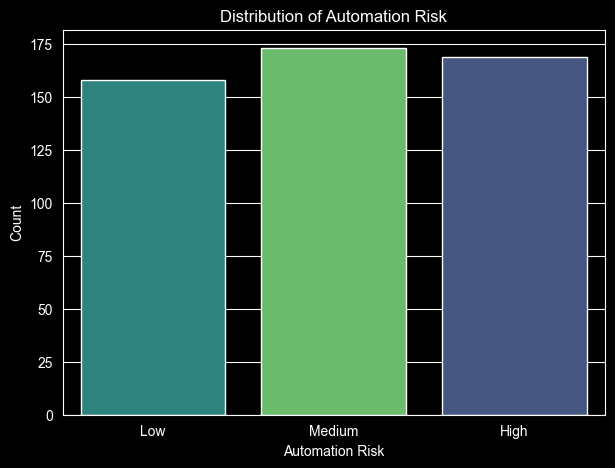

Automation_Risk
Medium    173
High      169
Low       158
Name: count, dtype: int64


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Automation Risk
plt.figure(figsize=(7, 5))
sns.countplot(x='Automation_Risk', data=df_clean, hue='Automation_Risk', palette='viridis', order=['Low', 'Medium', 'High'], legend=False)
plt.title('Distribution of Automation Risk')
plt.xlabel('Automation Risk')
plt.ylabel('Count')
plt.show()

print(df_clean['Automation_Risk'].value_counts())

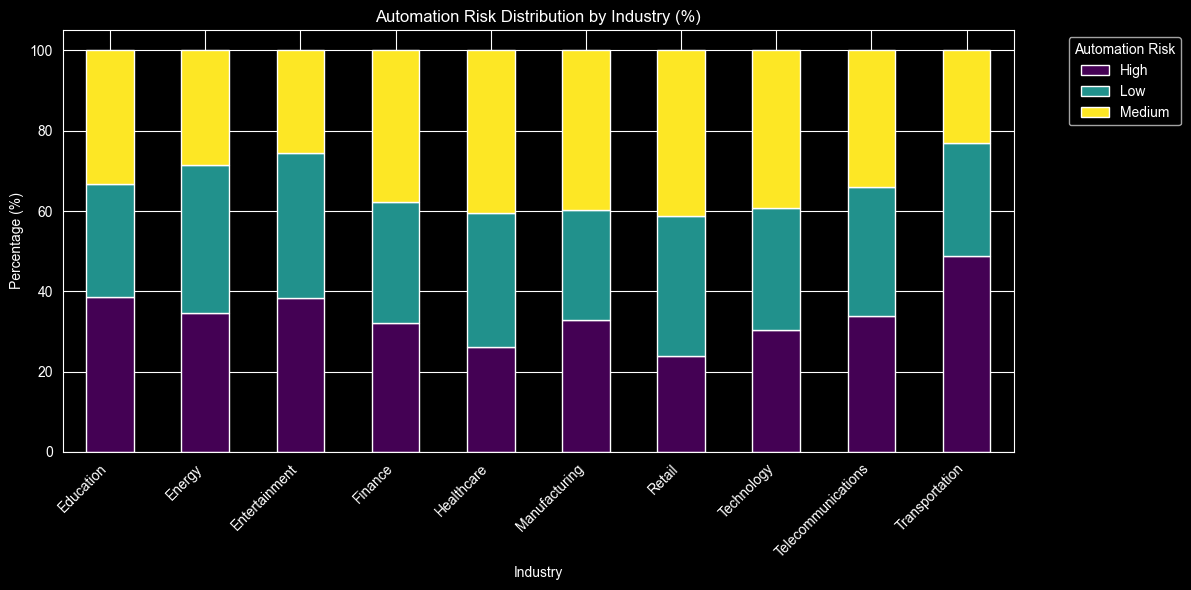

In [41]:
# Stacked bar chart - Automation Risk % by Industry
risk_industry = df_clean.groupby(['Industry', 'Automation_Risk']).size().unstack()
risk_industry_pct = risk_industry.div(risk_industry.sum(axis=1), axis=0) * 100

risk_industry_pct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Automation Risk Distribution by Industry (%)')
plt.xlabel('Industry')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Automation Risk', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

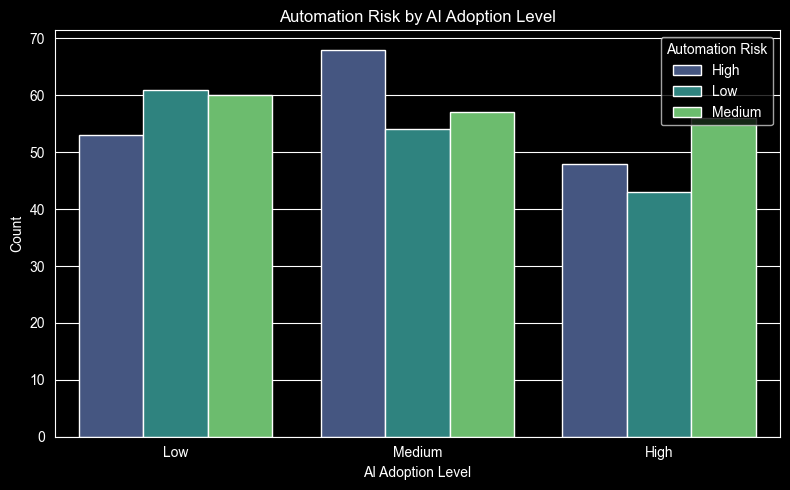

In [34]:
# Automation Risk by AI Adoption Level
plt.figure(figsize=(8, 5))
sns.countplot(x='AI_Adoption_Level', data=df_clean, hue='Automation_Risk', palette='viridis', order=['Low', 'Medium', 'High'])
plt.title('Automation Risk by AI Adoption Level')
plt.xlabel('AI Adoption Level')
plt.ylabel('Count')
plt.legend(title='Automation Risk')
plt.tight_layout()
plt.show()

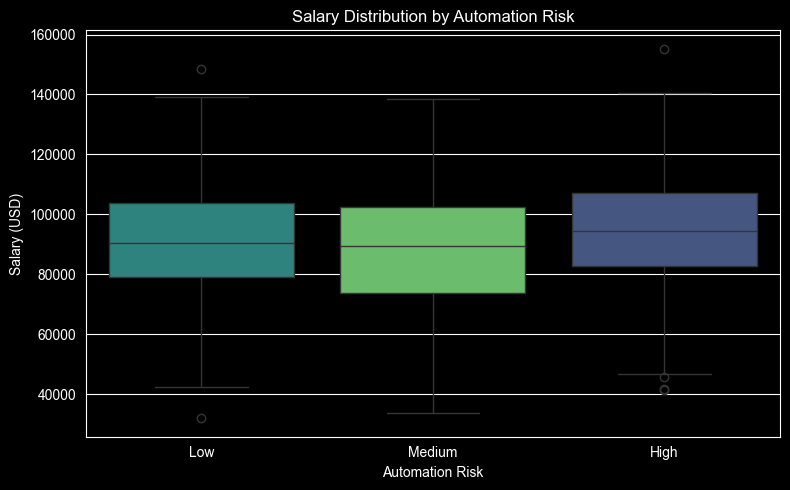

In [35]:
# Salary distribution by Automation Risk
plt.figure(figsize=(8, 5))
sns.boxplot(x='Automation_Risk', y='Salary_USD', data=df_clean, hue='Automation_Risk', palette='viridis', order=['Low', 'Medium', 'High'])
plt.title('Salary Distribution by Automation Risk')
plt.xlabel('Automation Risk')
plt.ylabel('Salary (USD)')
plt.tight_layout()
plt.show()

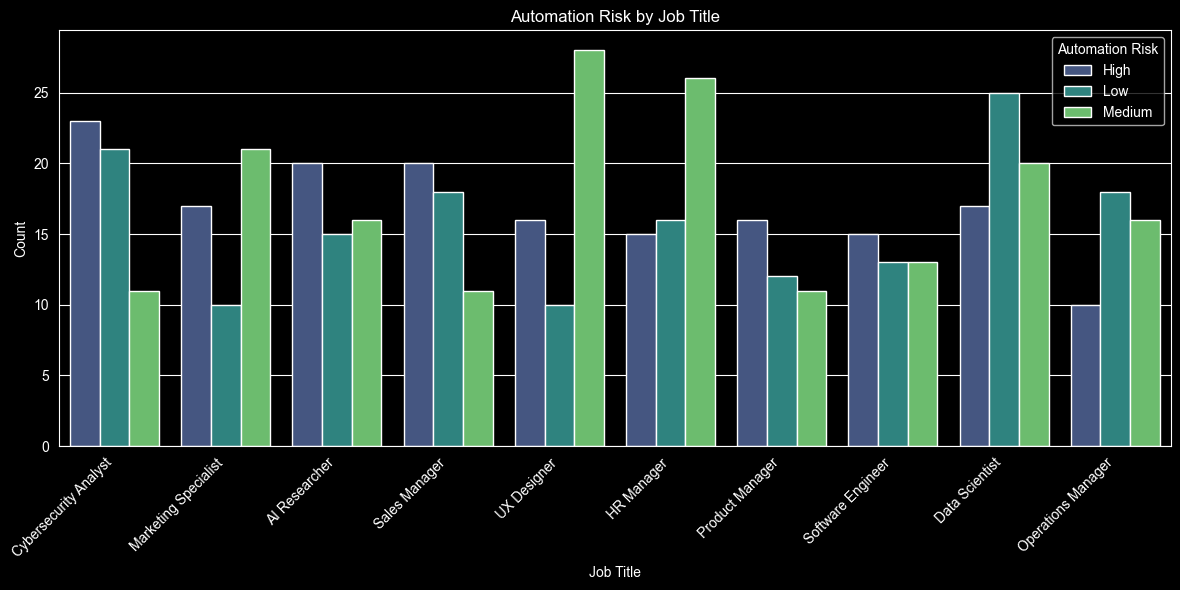

In [36]:
# Automation Risk by Job Title
plt.figure(figsize=(12, 6))
sns.countplot(x='Job_Title', data=df_clean, hue='Automation_Risk', palette='viridis')
plt.title('Automation Risk by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Automation Risk')
plt.tight_layout()
plt.show()

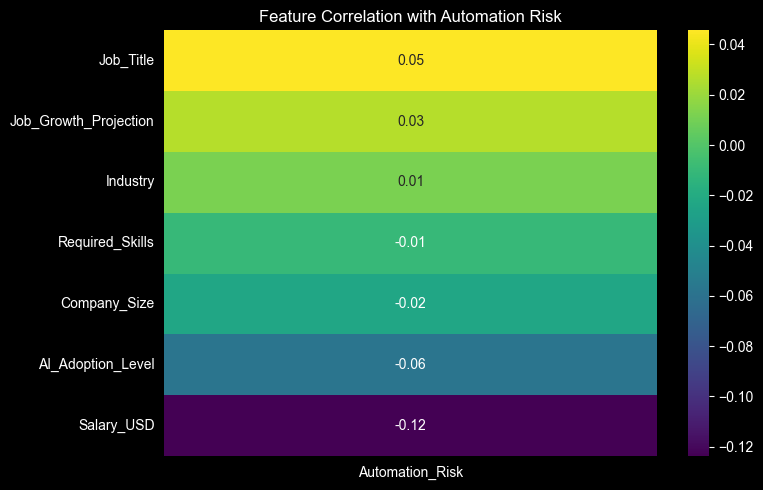

In [38]:
# Correlation with Automation_Risk only
plt.figure(figsize=(8, 5))
correlation = df_encoded.corr()[['Automation_Risk']].drop('Automation_Risk').sort_values('Automation_Risk', ascending=False)
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='viridis')
plt.title('Feature Correlation with Automation Risk')
plt.tight_layout()
plt.show()